# Feature Store de Telemetria — `datasets/D*`

Este notebook reconstrói, para **cada conjunto de dados** em `datasets/D*`, a
mesma *feature store* documentada em `Feature_Store_Telemetria.ipynb`. A
diferença está exclusivamente na origem da banda: os relatórios do protótipo
(`prototipo/relatorios`) produzem um `banda_raw_rota_*.csv` por rota, enquanto
cada conjunto em `datasets/` grava um único `banda.bwm`, com o `bwm-ng`
monitorando de uma só vez todas as interfaces do experimento (roteadores e
hosts). `feature_store/pipeline.py` ganhou, para este caso,
`ingerir_banda_arquivo_unico`: filtra apenas as interfaces atravessadas por
alguma rota e replica cada leitura para as rotas que a compartilham — o mesmo
efeito de `ingerir_banda`, partindo de uma fonte diferente.

## Conjuntos processados

| dataset | descrição |
|---|---|
| `D1`, `D1b` | linha de base, sem tráfego de fundo |
| `D2`, `D2b` | tráfego de fundo constante |
| `D3`, `D3b` | tráfego de fundo com um fluxo iperf longo |
| `D4`, `D4b` | tráfego de fundo com múltiplos fluxos iperf concorrentes |

`D3a` e `D4a` foram excluídos: contêm apenas o CSV largo de latência de uma
coleta secundária, sem `eventos.txt`, `banda.bwm`, `rotas.txt` ou `config.json`
— não há como reconstruir a store a partir deles.

## Saída

Para cada dataset `D`, a store é persistida em `feature_store/data/D/`, nos
mesmos dois layouts do notebook de referência (longo em `csv/`, largo
compatível com `datasets/D*` em `csv_ml/`). As tabelas em memória de todos os
datasets ficam disponíveis ao final em `resultados`, indexadas pelo nome do
dataset.

## 1. Importação

Reaproveita a mesma lógica de localização da raiz do projeto usada no notebook
de referência, necessária porque os caminhos relativos empregados
(`datasets/D*`) dependem do diretório de inicialização do kernel.

In [1]:
import os
import sys
from pathlib import Path


def raiz_do_projeto(marcadores=('prototipo', 'feature_store', 'datasets')):
    candidatos = [Path.cwd(), *Path.cwd().parents]
    for candidato in candidatos:
        if all((candidato / marcador).is_dir() for marcador in marcadores):
            return candidato
    raise RuntimeError(
        f'raiz do projeto não encontrada a partir de {Path.cwd()}. '
        f'Esperado um diretório contendo {marcadores}.'
    )


RAIZ = raiz_do_projeto()
os.chdir(RAIZ)
if str(RAIZ / 'feature_store') not in sys.path:
    sys.path.insert(0, str(RAIZ / 'feature_store'))

print(f'raiz do projeto : {RAIZ}')
print(f'interpretador   : {sys.executable}')
print(f'python          : {sys.version.split()[0]}')

raiz do projeto : /Users/pamella.martins/mestrado/dissertacao/path-aware-datasets
interpretador   : /Users/pamella.martins/mestrado/dissertacao/path-aware-datasets/.venv/bin/python
python          : 3.14.0


In [2]:
import glob

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import pipeline as fs

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 80)

print(f'pandas {pd.__version__} | numpy {np.__version__}')

pandas 3.0.5 | numpy 2.5.2


## 2. Descoberta dos datasets

Um dataset é elegível quando dispõe simultaneamente de `banda.bwm`,
`eventos.txt`, `rotas.txt` e `config.json` — os quatro insumos exigidos por
`fs.construir`.

In [3]:
def dataset_elegivel(pasta):
    exigidos = ['banda.bwm', 'eventos.txt', 'rotas.txt', 'config.json']
    return all(os.path.exists(os.path.join(pasta, arquivo)) for arquivo in exigidos)


todas_as_pastas = sorted(glob.glob('datasets/D*'))
datasets = [os.path.basename(p) for p in todas_as_pastas if dataset_elegivel(p)]
descartados = [os.path.basename(p) for p in todas_as_pastas if not dataset_elegivel(p)]

print(f"datasets elegíveis  ({len(datasets)}): {datasets}")
print(f"datasets descartados ({len(descartados)}): {descartados}")

datasets elegíveis  (8): ['D1', 'D1b', 'D2', 'D2b', 'D3', 'D3b', 'D4', 'D4b']
datasets descartados (2): ['D3a', 'D4a']


## 3. Construção da store por dataset

`fs.construir` recebe `arquivo_banda` apontando para o `banda.bwm` do dataset,
o que roteia a ingestão para `ingerir_banda_arquivo_unico` em vez de
`ingerir_banda`. `pasta_relatorios` e `caminho_config` apontam para a própria
pasta do dataset, de onde vêm `eventos.txt`, `rotas.txt` e `config.json`.

A tolerância de separação de execuções (`gap_maximo_s`) é maior que o padrão
usado em `prototipo/relatorios`: o `banda.bwm` acumula, em uma única coleta
contínua, lacunas isoladas de 1–2 s por amostras perdidas do `bwm-ng`, que a
tolerância padrão de 1 s fragmentaria indevidamente em execuções distintas.
`inferir_alinhamento` já aplica 5 s automaticamente quando `arquivo_banda` é
informado.

In [4]:
resultados = {}
falhas = {}

for dataset in datasets:
    pasta = f'datasets/{dataset}'
    try:
        resultado = fs.construir(
            pasta_relatorios=pasta,
            caminho_config=f'{pasta}/config.json',
            pasta_destino=f'feature_store/data/{dataset}',
            arquivo_banda=f'{pasta}/banda.bwm',
        )
        resultados[dataset] = resultado
    except Exception as erro:
        falhas[dataset] = erro

print(f"{'dataset':8s} {'residuo_s':>9s} {'registros':>10s} {'rotas':>6s} {'lat. preenchida':>16s}")
print('-' * 60)
for dataset, resultado in resultados.items():
    view = resultado['view']
    al = resultado['alinhamento']
    print(f"{dataset:8s} {al['residuo_s']:9.1f} {len(view):10d} "
          f"{view.rota_id.nunique():6d} {view.latencia_ms.notna().sum():7d}/{len(view):<7d}")

if falhas:
    print()
    print("falhas:")
    for dataset, erro in falhas.items():
        print(f"  {dataset}: {erro}")

dataset  residuo_s  registros  rotas  lat. preenchida
------------------------------------------------------------
D1             0.0      14390      4   14386/14390  
D1b            0.0      14380      4   14376/14380  
D2             0.0      14634      4   14630/14634  
D2b            0.0      14580      4   14576/14580  
D3             0.0      14644      4   14640/14644  
D3b            0.0      14626      4   14622/14626  
D4             0.0      15398      4   15394/15398  
D4b            0.0      15066      4   15062/15066  


## 4. Persistência

`fs.construir` já persiste cada store em `feature_store/data/<dataset>/`
(parâmetro `pasta_destino`), nos mesmos dois layouts do notebook de
referência. A célula seguinte apenas lista o que foi gravado.

In [5]:
for dataset in resultados:
    pasta = f'feature_store/data/{dataset}'
    arquivos = sorted(glob.glob(f'{pasta}/csv/*.csv') + glob.glob(f'{pasta}/csv_ml/*'))
    total_bytes = sum(os.path.getsize(a) for a in arquivos)
    print(f"{dataset}: {len(arquivos)} arquivos, {total_bytes:,} bytes em {pasta}/")

D1: 8 arquivos, 11,518,776 bytes em feature_store/data/D1/
D1b: 8 arquivos, 11,363,168 bytes em feature_store/data/D1b/
D2: 8 arquivos, 12,453,152 bytes em feature_store/data/D2/
D2b: 8 arquivos, 12,286,148 bytes em feature_store/data/D2b/
D3: 8 arquivos, 12,516,648 bytes em feature_store/data/D3/
D3b: 8 arquivos, 12,296,927 bytes em feature_store/data/D3b/
D4: 8 arquivos, 13,285,272 bytes em feature_store/data/D4/
D4b: 8 arquivos, 13,032,050 bytes em feature_store/data/D4b/


## 4.1 Arquivos de output e significado das features

### Arquivos gerados por dataset

Para cada `feature_store/data/<DATASET>/`, o pipeline grava dois layouts:

**Layout longo** (`csv/`) — um arquivo por feature group, grão explícito na chave:

| arquivo | grão | conteúdo |
|---|---|---|
| `fg_latencia.csv` | (run, rota, ts) | RTT medido por ping |
| `fg_banda_interface.csv` | (run, rota, interface, ts) | taxa e utilização por interface |
| `fg_banda_rota.csv` | (run, rota, ts) | gargalo e agregados do caminho |
| `consolidado.csv` | (run, rota, ts) | junção, features de janela, deltas e alvo — a tabela principal |
| `dim_rota.csv` | (rota) | atributos fixos do caminho (dimensão) |

**Layout largo** (`csv_ml/`) — compatível com `datasets/D*`, uma coluna por rota:

| arquivo | conteúdo |
|---|---|
| `latencia_rotas_h1_h6.csv` | latência (ms) de cada rota, uma coluna por rota, indexado por `timestamp` |
| `banda_rotas_h1_h6.csv` | gargalo (Mbps) de cada rota, mesmo layout |
| `rotulos_h1_h6.txt` | índice (base 1) da rota de menor latência em cada instante |

### Significado das colunas de `consolidado`

**Chaves e identificadores**

| coluna | significado |
|---|---|
| `run_id` | identificador da execução válida dentro do dataset (após resolução do alinhamento) |
| `rota_id` | caminho de rede ao qual a observação pertence (`h11_h61`, `h12_h62`, `h13_h63`, `h14_h64`) |
| `ts_epoch` | instante da observação, em segundos Unix, na escala comum de banda e latência |
| `datetime_utc` | mesmo instante, em formato de data/hora |
| `tempo_relativo_s` | segundos decorridos desde o início da coleta (uso em gráficos, não em junções) |

**Métricas instantâneas**

| coluna | significado |
|---|---|
| `latencia_ms` | RTT medido pelo ping naquele segundo; `NaN` quando o ping não respondeu |
| `gargalo_Mbps` | banda disponível na interface mais congestionada do caminho — limita a vazão útil da rota |
| `banda_media_Mbps` | média da banda disponível entre todas as interfaces do caminho |
| `util_max_pct` | maior utilização (%) observada entre as interfaces do caminho |

**Features de janela deslizante** (janelas `micro`=5s, `curta`=15s, `longa`=30s)

| padrão de coluna | significado |
|---|---|
| `latencia_p95_{janela}` | pior latência típica na janela (percentil 95) |
| `latencia_jitter_{janela}` | desvio padrão da latência na janela — instabilidade |
| `latencia_media_{janela}` | latência média suavizada na janela |
| `gargalo_min_{janela}` | pior gargalo observado na janela |
| `banda_media_{janela}` | banda média disponível na janela |
| `utilizacao_media_{janela}` | utilização média (0–1) na janela |

**Deltas e features cruzadas**

| coluna | significado |
|---|---|
| `latencia_delta_micro_longa` | tendência: latência média recente (5s) menos a média de contexto (30s) |
| `banda_delta_micro_longa` | severidade do gargalo atual: pior gargalo recente (5s) sobre banda média de contexto (30s) |
| `bdp` | *Bandwidth-Delay Product* (`gargalo_Mbps × latencia_ms`) — volume estimado de dados em trânsito |

**Alvo**

| coluna | significado |
|---|---|
| `melhor_rota` | índice (base 1) da rota de menor latência naquele instante; **função determinística da latência** (vazamento de rótulo, ver Seção 8) |

**Dimensão da rota** (`dim_rota`, incluída apenas com `incluir_dim_rota=True`)

| coluna | significado |
|---|---|
| `caminho` | sequência de switches/hosts percorrida pela rota |
| `n_links_sw` | número de enlaces inter-switch (proxy de número de saltos) |
| `atraso_cfg_ms` | RTT teórico configurado no TCLink para o caminho |

A coluna adicional `dataset_id`, presente apenas no resultado de
`get_features_todos` (Seção 7), identifica de qual dataset (`D1`, `D2` etc.)
cada linha se origina — não existe nos CSVs individuais de cada store.

## 5. Verificação

Reaplica, para cada dataset, as verificações estruturais do notebook de
referência (Seção 10): ausência de colunas integralmente nulas, contagem
consistente de rotas e concentração dos valores ausentes de latência na
inicialização do ping.

In [8]:
for dataset, resultado in resultados.items():
    view = resultado['view']

    assert not [c for c in view.columns if view[c].isna().all()], \
        f'{dataset}: há coluna integralmente nula'

    # As contagens por rota podem diferir por poucos segundos: cada rota tem
    # sua propria janela de amostragem de banda, e amostras isoladas do
    # bwm-ng podem faltar em uma interface e nao em outra. Verifica-se
    # proximidade, nao igualdade estrita.
    contagens = view.rota_id.value_counts()
    dispersao = contagens.max() - contagens.min()
    assert dispersao <= 10, \
        f'{dataset}: rotas com contagens muito diferentes de registros: {contagens.to_dict()}'

    ausentes = view[view.latencia_ms.isna()]
    if len(ausentes):
        # As amostras sem latência devem concentrar-se no início da coleta
        # (inicialização do ping), não espalhadas ao longo da série
        limite = view.ts_epoch.min() + 3
        assert ausentes.ts_epoch.max() <= limite, \
            f'{dataset}: valores ausentes de latência fora da inicialização do ping'

print(f"verificações estruturais aprovadas para {len(resultados)} datasets")

verificações estruturais aprovadas para 8 datasets


## 6. Visualização de validação

Gargalo e latência ao longo do tempo, lado a lado para todos os datasets, como
checagem visual de que o alinhamento e a agregação produziram séries
coerentes com o cenário de cada coleta (linha de base, tráfego de fundo
constante ou fluxos iperf concorrentes).

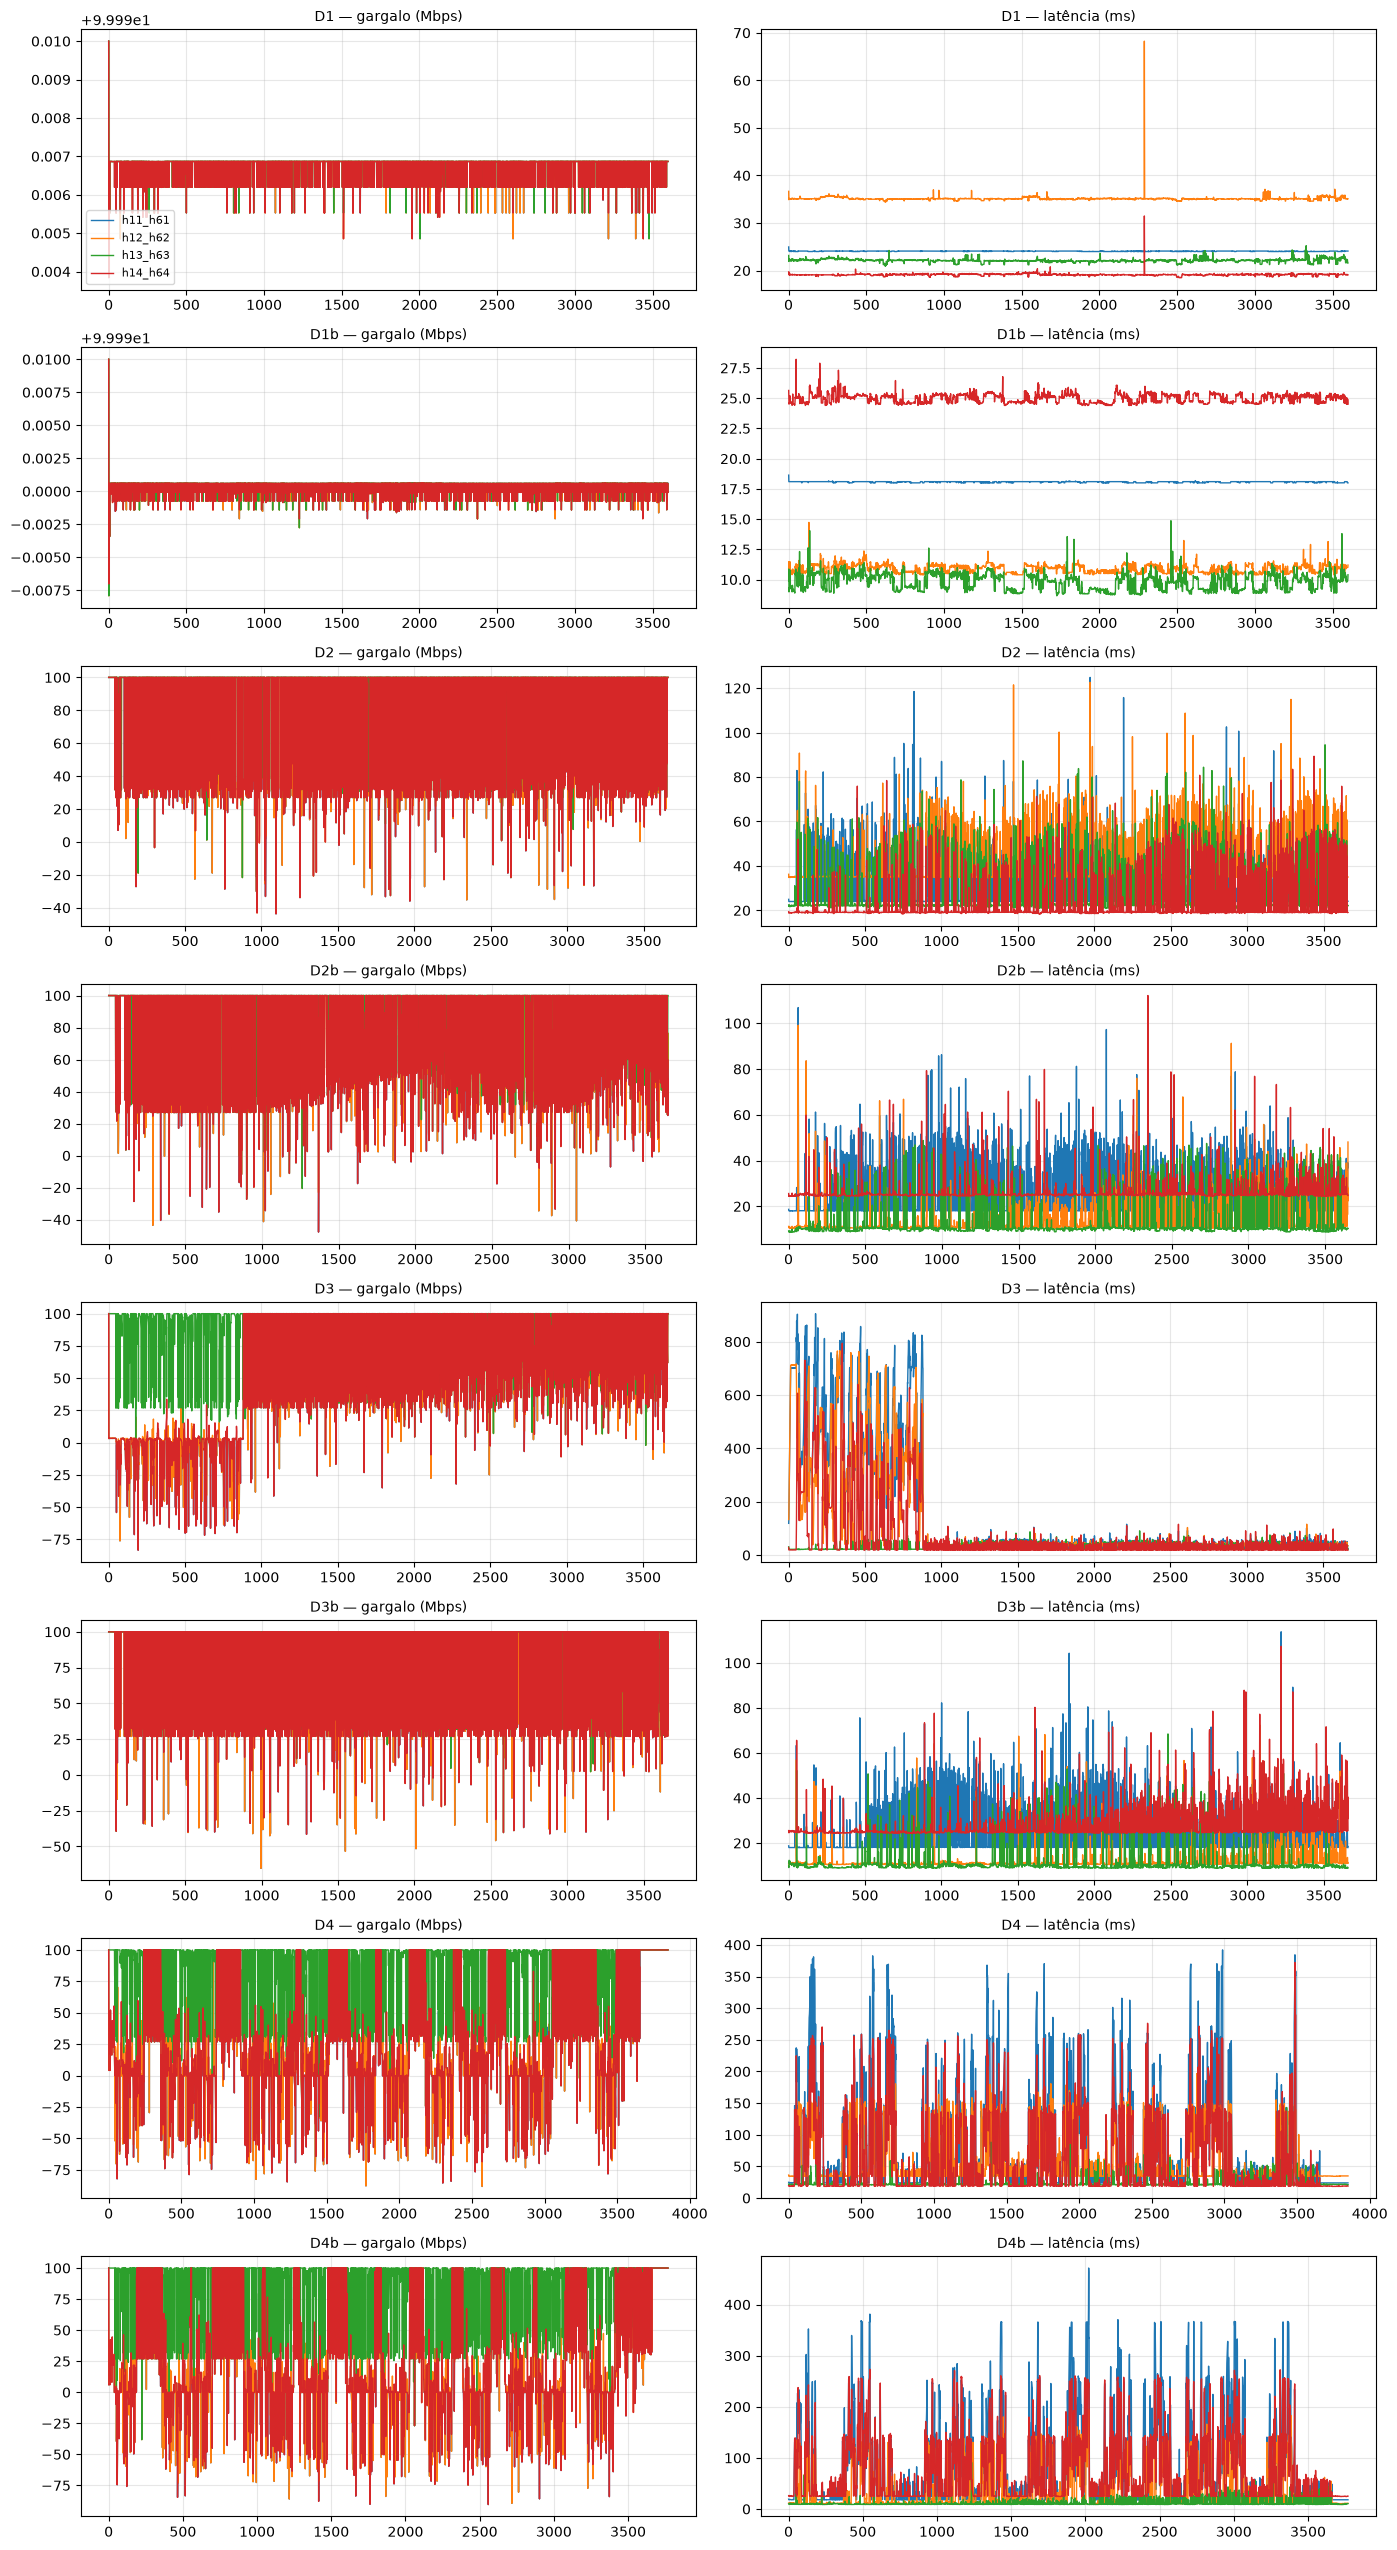

In [9]:
n = len(resultados)
fig, eixos = plt.subplots(n, 2, figsize=(14, 3.2 * n), squeeze=False)

for linha, (dataset, resultado) in enumerate(resultados.items()):
    view = resultado['view']
    ax_banda, ax_latencia = eixos[linha]

    for rota, grupo in view.groupby('rota_id'):
        ax_banda.plot(grupo.tempo_relativo_s, grupo.gargalo_Mbps, label=rota, linewidth=1)
        ax_latencia.plot(grupo.tempo_relativo_s, grupo.latencia_ms, label=rota, linewidth=1)

    ax_banda.set_title(f'{dataset} — gargalo (Mbps)', fontsize=10)
    ax_latencia.set_title(f'{dataset} — latência (ms)', fontsize=10)
    ax_banda.grid(alpha=0.3)
    ax_latencia.grid(alpha=0.3)
    if linha == 0:
        ax_banda.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()

## 7. Consulta consolidada entre datasets

Como cada dataset é persistido em sua própria pasta, `get_features` é chamado
uma vez por dataset e as tabelas resultantes são concatenadas com uma coluna
adicional `dataset_id`, permitindo comparações entre coletas sem misturar
`run_id` (que é local a cada store).

In [10]:
def get_features_todos(datasets=resultados.keys(), **kwargs):
    partes = []
    for dataset in datasets:
        parte = fs.get_features(pasta_origem=f'feature_store/data/{dataset}', **kwargs)
        parte.insert(0, 'dataset_id', dataset)
        partes.append(parte)
    return pd.concat(partes, ignore_index=True)


completo = get_features_todos()
print(f"conjunto completo: {completo.shape[1]} colunas, {len(completo)} registros")
print(f"datasets: {sorted(completo.dataset_id.unique())}")
completo.head()

conjunto completo: 32 colunas, 117718 registros
datasets: ['D1', 'D1b', 'D2', 'D2b', 'D3', 'D3b', 'D4', 'D4b']


,dataset_id,run_id,rota_id,ts_epoch,datetime_utc,tempo_relativo_s,gargalo_Mbps,banda_media_Mbps,util_max_pct,latencia_ms,latencia_p95_micro_5s,latencia_jitter_micro_5s,latencia_media_micro_5s,gargalo_min_micro_5s,banda_media_micro_5s,utilizacao_media_micro_5s,latencia_p95_curta_15s,latencia_jitter_curta_15s,latencia_media_curta_15s,gargalo_min_curta_15s,banda_media_curta_15s,utilizacao_media_curta_15s,latencia_p95_longa_30s,latencia_jitter_longa_30s,latencia_media_longa_30s,gargalo_min_longa_30s,banda_media_longa_30s,utilizacao_media_longa_30s,latencia_delta_micro_longa,bdp,banda_delta_micro_longa,melhor_rota
0,D1,0,h11_h61,1764165622,2025-11-26 14:00:22,0,100.00000,100.000000,0.00000,NaN,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,1.000000,<NA>
1,D1,0,h12_h62,1764165622,2025-11-26 14:00:22,0,100.00000,100.000000,0.00000,NaN,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,1.000000,<NA>
2,D1,0,h13_h63,1764165622,2025-11-26 14:00:22,0,100.00000,100.000000,0.00000,NaN,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,1.000000,<NA>
3,D1,0,h14_h64,1764165622,2025-11-26 14:00:22,0,100.00000,100.000000,0.00000,NaN,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,NaN,100.00000,100.000000,0.000000,NaN,NaN,1.000000,<NA>
4,D1,0,h11_h61,1764165623,2025-11-26 14:00:23,1,99.99384,99.994251,0.00616,24.962602,24.962602,NaN,24.962602,99.99384,99.997125,0.000031,24.962602,NaN,24.962602,99.99384,99.997125,0.000031,24.962602,NaN,24.962602,99.99384,99.997125,0.000031,0.0,2496.106453,0.999967,4


## 8. Limitações

**Correção de unidade não aplicada aqui.** Diferente de `Feature_Store_Telemetria.ipynb`,
que reprocessa a partir de `banda_raw_rota_*.csv` cru, os datasets/D* já foram
gerados por uma versão anterior do protótipo; `banda.bwm` é a captura bruta do
`bwm-ng`, então a mesma correção de unidade (bytes/s → Mbps decimal, sem passar
por Mibit/s) se aplica igualmente aqui. As pequenas diferenças residuais frente
a `banda_rota_*.txt` (na ordem de poucos Mbps em cenários com tráfego
concorrente) refletem o mesmo efeito de arredondamento documentado no notebook
de referência, não um erro de reprocessamento.

**Volume por dataset.** Cada conjunto cobre uma execução de aproximadamente uma
hora (3600–3850 s úteis por rota), muito maior que a coleta de referência (30 s),
mas ainda uma única execução por cenário — não há repetições que permitam
estimar variância entre execuções do mesmo cenário.

**Vazamento no alvo.** A coluna `melhor_rota` permanece função determinística
da latência em todos os datasets, pela mesma razão descrita no notebook de
referência.